## ⚠️ Notice

## This material is the intellectual property of <font color="cyan">Dr. Lysa V. Comia.</font>  



Redistribution, reproduction, or use beyond personal reference is strictly prohibited without the prior written consent of the author.

## Connect Google Drive

In [ ]:
from google.colab import drive

# Mount Google Drive to access datasets, pretrained models, and save training outputs.
# When prompted, follow the authorization link and paste the access code below.

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Installation

In [ ]:
# Navigate to the project directory in Google Drive
# Ensure this path matches the location of your YOLOv12 project files.

%cd '/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation'

/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation


In [ ]:
# Clone the YOLOv12 repository
# (Uncomment this code below if cloning for the first time,
# then comment it out again after the initial setup to avoid recloning.)

#!git clone https://github.com/sunsmarterjie/yolov12.git

In [ ]:
# Move into the YOLOv12 repository directory
# This assumes you have already cloned or copied the yolov12 folder inside your project path.

%cd yolov12

/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/yolov12


In [ ]:
# Install project dependencies
# We overwrite requirements.txt with fixed versions to ensure compatibility in Colab.
# This prevents mismatched or outdated package versions during installation.

%%writefile requirements.txt
torch==2.8.0
torchvision==0.23.0
timm==1.0.14
albumentations==2.0.4
pycocotools==2.0.7
PyYAML==6.0.3
scipy==1.16.2
onnxslim==0.1.31
onnxruntime-gpu==1.18.0
gradio==5.48.0
opencv-python==4.9.0.80
psutil==5.9.8
py-cpuinfo==9.0.0
huggingface-hub==0.34.0
safetensors==0.4.3
numpy==1.26.4
supervision==0.22.0
websockets==15.0.1

Overwriting requirements.txt


In [ ]:
!pip install -r requirements.txt

  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
Using cached setuptools-80.9.0-py3-none-any.whl (1.2 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
# Upgrade core packaging tools to the latest versions
# Ensures smooth installation of dependencies and prevents build errors.
!pip install -U pip setuptools wheel

  Using cached pip-25.3-py3-none-any.whl.metadata (4.7 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
Using cached pip-25.3-py3-none-any.whl (1.8 MB)
Using cached setuptools-80.9.0-py3-none-any.whl (1.2 MB)
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
# Install ONNX with prebuilt binaries only (no source build)
# This avoids compilation errors in Colab by forcing a wheel install.
!pip install --only-binary=:all: "onnx==1.16.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 38.3 MB/s  0:00:00
  Attempting uninstall: onnx
    Found existing installation: onnx 1.19.1
    Uninstalling onnx-1.19.1:
      Successfully uninstalled onnx-1.19.1


In [ ]:
# Change directory to the YOLOv12 repository inside your project folder
# Make sure the yolov12 folder exists in this path before running.
%cd '/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/yolov12'

/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/yolov12


In [ ]:
# Reinstall FlashAttention to ensure compatibility with Colab environment
# Step 1: Uninstall any conflicting versions
!pip uninstall -y flash-attn flash_attn

# Step 2: Force reinstall the correct version (2.8.3) without using cache
!pip install --no-cache-dir --force-reinstall "flash-attn==2.8.3"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 59.1 MB/s  0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
ERROR: Failed to build 'flash-attn' when getting requirements to build wheel


In [ ]:
# Reinstall compatible versions of fsspec and install jedi after flash-attn installation
!pip install --force-reinstall "fsspec==2025.3.0" "jedi>=0.16"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.6 MB/s  0:00:00
  Attempting uninstall: parso
    Found existing installation: parso 0.8.5
    Uninstalling parso-0.8.5:
      Successfully uninstalled parso-0.8.5
  Attempting uninstall: fsspec
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/3 [parso]    WARNING: Ignoring invalid distribution ~etuptools (/usr/local/lib/python3.12/dist-packages)
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [jedi]


In [ ]:
# Navigate back into the YOLOv12 project directory
# This ensures subsequent training or evaluation commands run inside the repo.
%cd '/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/yolov12'

/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/yolov12


In [ ]:
# Install YOLOv12 in editable/development mode
# This allows you to modify the repository code and immediately use the changes without reinstalling.
!pip install -e .

Obtaining file:///content/drive/MyDrive/Colab%20Notebooks/Ear_Segmentation/yolov12
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyproject.toml) ... done
  Created wheel for ultralytics: filename=ultralytics-8.3.63-0.editable-py3-none-any.whl size=20272 sha256=5c949da6fd447cc6891a418aada2e906d71b69ce2c3a80c9983fa9ae003b6db4
  Stored in directory: /tmp/pip-ephem-wheel-cache-09mzt0za/wheels/bf/b6/af/6a664cf049b6c4ac1eba1e800ddb8820fe070a957d3d94a9b0
Successfully built ultralytics
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ultralytics]


In [ ]:
# Ensure we are inside the YOLOv12 repository directory
# This is important before running training, validation, or inference scripts.
%cd '/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/yolov12'

/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/yolov12


In [ ]:
# Install the specific Ultralytics version required for YOLOv12
# -U flag upgrades if an older version is already installed
!pip install -U ultralytics==8.3.211

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 6.7 MB/s  0:00:00
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.3.63
    Uninstalling ultralytics-8.3.63:
      Successfully uninstalled ultralytics-8.3.63


In [ ]:
# Download YOLOv12/YOLOv11 pretrained weights
# ⚠️ IMPORTANT: Uncomment ONLY the line you need, then comment it again after the first run
# to avoid downloading the file repeatedly in Colab.

# 📖 Full documentation and complete list of YOLOv12 model variants:
# https://docs.ultralytics.com/models/yolo12/

# --- For Object Detection ---
#!wget https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo12n.pt

# --- For Object Segmentation ---
#!wget https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n-seg.pt


--2025-10-25 16:47:49--  https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n-seg.pt
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/74bee05a-9e86-48b4-b611-b3204f4d9349?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-10-25T17%3A46%3A52Z&rscd=attachment%3B+filename%3Dyolo11n-seg.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-10-25T16%3A46%3A40Z&ske=2025-10-25T17%3A46%3A52Z&sks=b&skv=2018-11-09&sig=o%2BKv0HzCPECucQ2B8jzhU5%2BoIJW7o6L0aklwILgibQ4%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2MTQxMTE3MCwibmJmIjoxNzYxNDEwODcwLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ib

## Training

In [ ]:
from ultralytics import YOLO

# Initialize the YOLO model
# ⚠️ Use the appropriate checkpoint:
# - yolo12n.pt       → for object detection
# - yolo11n-seg.pt   → for object segmentation
model = YOLO('/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/yolov12/yolo11n-seg.pt')

# Train the model
results = model.train(
    data='/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/data.yaml',  # dataset config file
    epochs=1000,       # maximum epochs (early stopping may end sooner)
    patience=15,       # stop if no improvement for 15 epochs
    batch=8,           # batch size
    imgsz=640,         # input image size
    scale=0.5,         # data augmentation scaling
    mosaic=1.0,        # mosaic augmentation probability
    mixup=0.0,         # mixup probability
    copy_paste=0.1,    # copy-paste augmentation probability
    close_mosaic=10,   # disable mosaic augmentation in the last 10 epochs
    device=0,          # set to "0" for GPU, "cpu" for CPU
    save=True,         # save both best.pt and last.pt
    project='/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/runs' # Save results to Google Drive
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/yolov12/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
New https://pypi.org/project/ultralytics/8.3.221 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=segment, mode=train, model=/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/yolov12/yolo11n-seg.pt, data=/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/data.yaml, epochs=1000, time=None, patience=15, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/runs, name=train, exist_ok=False, p

100%|██████████| 755k/755k [00:00<00:00, 26.2MB/s]


Overriding model.yaml nc=80 with nc=5

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 5.26M/5.26M [00:00<00:00, 100MB/s]


AMP: checks passed ✅


...

    61/1000       1.5G     0.5028     0.8867     0.3665      1.104         17        640: 100%|██████████| 877/877 [04:14<00:00,  3.45it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 19/19 [00:05<00:00,  3.64it/s]

                   all        292        292      0.999          1      0.995       0.92      0.999          1      0.995      0.917
EarlyStopping: Training stopped early as no improvement observed in last 15 epochs. Best results observed at epoch 46, best model saved as best.pt.
To update EarlyStopping(patience=15) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



61 epochs completed in 4.464 hours.
Optimizer stripped from /content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/runs/train/weights/last.pt, 6.0MB
Optimizer stripped from /content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/runs/train/weights/best.pt, 6.0MB

Validating /content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/runs/train/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n-seg summary (fused): 265 layers, 2,835,543 parameters, 0 gradients, 9.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 19/19 [00:09<00:00,  2.09it/s]


                   all        292        292      0.998          1      0.995      0.928      0.998          1      0.995       0.92
                   aom         55         55      0.997          1      0.995      0.991      0.997          1      0.995      0.995
                    ci         63         63      0.999          1      0.995      0.968      0.999          1      0.995      0.964
                   com         51         51      0.998          1      0.995      0.882      0.998          1      0.995      0.856
                   mys         46         46      0.999          1      0.995      0.874      0.999          1      0.995      0.851
                  norm         77         77      0.998          1      0.995      0.923      0.998          1      0.995      0.936
Speed: 0.4ms preprocess, 5.9ms inference, 0.0ms loss, 4.8ms postprocess per image
Results saved to /content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/runs/train


## Testing


image 1/1 /content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/test/images/norm-584-_jpg.rf.184c28d87c6679a90ca64c29cf3d8246.jpg: 640x640 1 norm, 15.5ms
Speed: 2.8ms preprocess, 15.5ms inference, 5.1ms postprocess per image at shape (1, 3, 640, 640)


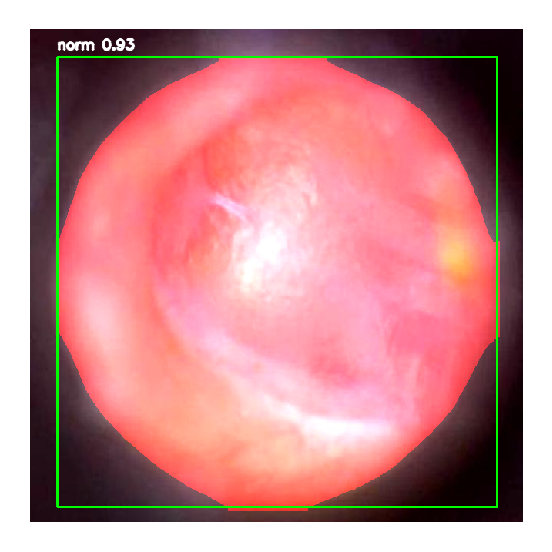

In [ ]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt
import numpy as np

# Load trained YOLOv12 segmentation model weights
model = YOLO("/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/runs/train/weights/best.pt")

# Test image path
img_path = "/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/test/images/norm-584-_jpg.rf.184c28d87c6679a90ca64c29cf3d8246.jpg"

# Run inference
results = model(img_path)

# Process and visualize results
for r in results:
    # Load the original image (full resolution)
    img = cv2.imread(img_path)

    # Overlay segmentation masks
    if r.masks is not None:
        masks = r.masks.data.cpu().numpy()
        for mask in masks:
            mask = mask.astype(np.uint8) * 255
            colored_mask = np.zeros_like(img)
            colored_mask[:, :, 2] = mask  # Red overlay for segmentation
            img = cv2.addWeighted(img, 1.0, colored_mask, 0.5, 0)

    # Draw bounding boxes, labels, and confidence scores
    boxes = r.boxes.xyxy.cpu().numpy()
    scores = r.boxes.conf.cpu().numpy()       # confidence scores
    class_ids = r.boxes.cls.cpu().numpy().astype(int)  # class IDs
    names = model.names                       # class name mapping

    for box, score, cls_id in zip(boxes, scores, class_ids):
        x1, y1, x2, y2 = map(int, box)
        label = f"{names[cls_id]} {score:.2f}"  # e.g. "tilapia 0.93"

        # Draw rectangle
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Put label + score above the box
        cv2.putText(img, label, (x1, max(y1 - 10, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2,
                    lineType=cv2.LINE_AA)

    # Display image at original resolution
    h, w = img.shape[:2]
    dpi = 300
    fig_w, fig_h = w / dpi, h / dpi
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)

    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), interpolation='nearest')
    ax.axis("off")
    plt.show()


## Logs

In [ ]:
# --------------------------------------------------------------
# Save and Collect Training Logs
# These logs will later be used for data visualization
# (e.g., loss curves, mAP, precision/recall) in documentation or papers.
# --------------------------------------------------------------

import shutil

# Define source (YOLO training logs) and destination (your Drive folder for papers)
src = "/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/runs"
dst = "/content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/logs_for_visualization"

# Copy all run logs (metrics, results.csv, tensorboard files, etc.)
shutil.copytree(src, dst, dirs_exist_ok=True)

print(f"✅ Logs copied to: {dst}")


✅ Logs copied to: /content/drive/MyDrive/Colab Notebooks/Ear_Segmentation/logs_for_visualization


# ⚠️ Notice

## This material is the intellectual property of <font color="cyan">Dr. Lysa V. Comia.</font>  


## 📌 Notice on Use, Redistribution, and Ethical Compliance  

Redistribution, reproduction, or use of this material beyond personal reference is **strictly prohibited** without the prior written consent of the author. Unauthorized copying, modification, or dissemination—whether for commercial, academic, or institutional purposes—violates intellectual property rights and may result in legal or disciplinary action.  

---

### 🔒 AI Governance and Ethics Considerations  
This work must **not** be used in ways that:  
- ❌ **Compromise data privacy** or violate data protection regulations (e.g., GDPR, Philippine Data Privacy Act).  
- ❌ **Perpetuate bias or discrimination** by misusing algorithms, datasets, or results.  
- ❌ **Enable harmful applications**, including surveillance, profiling, or uses that undermine human rights.  
- ❌ **Misrepresent authorship or credit**, such as plagiarism or omission of proper citations.  

---

### ✅ Responsible Use Principles  
Users are expected to follow responsible research and innovation practices, ensuring that any derivative work is:  
- **Transparent** → Clear acknowledgment of sources and methodology.  
- **Accountable** → Proper attribution and disclosure of limitations.  
- **Beneficial to society** → Applications that align with ethical standards and do not cause harm.  

---

📢 For **any intended use** (academic, research, or practical), prior written approval must be obtained from the author to ensure compliance with both **legal requirements** and **ethical AI practices**.  
